# Phase III: Envelope optimization integrated into surroundings

**Building:** H Building · **Model:** `models/h_envelope_wwr20.idf` · **Weather:** `weather/BRA_RS_Passo.Fundo.869630_TMYx.2007-2021.epw` · **Output:** `results/h_envelope_wwr20_results.csv`

Multi-objective optimization (NSGA-II via BESOS) minimizing cooling and heating demand with nine envelope and natural-ventilation variables. Run this notebook from its own folder (paths are relative to `notebooks/`).

## Envelope optimization


### *Import* of libraries

In [1]:
from besos import eppy_funcs as ef
from besos import eplus_funcs as ep
from besos.problem import EPProblem
from besos.objectives import *
from besos.evaluator import EvaluatorEP
from besos.parameters import wwr, RangeParameter, FieldSelector, FilterSelector, GenericSelector, Parameter, expand_plist
from besos.optimizer import NSGAII, SPEA2
from platypus.evaluator import MapEvaluator
import platypus
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
from dask.distributed import Client

### Simulation Model

In [2]:
building = ef.get_building('../models/h_envelope_wwr20.idf') # Loading the E+ model;

### Variables

In [3]:
parameters = []

parameters.append(
            Parameter(
                selector=FieldSelector(
                    class_name="MATERIAL",             # Class of E+;
                    object_name="Rockwool_north",    # Object name;
                    field_name="Thickness", # Object field;
                ),
                name='IT - North Ext. Walls',
                value_descriptor=RangeParameter(min_val=0.0001, max_val=0.15)      # Range
                )
            )

parameters.append(
            Parameter(
                selector=FieldSelector(
                    class_name="MATERIAL",             # Class of E+;
                    object_name="Rockwool_south",    # Object name;
                    field_name="Thickness", # Object field;
                ),
                name='IT - South Ext. Walls',
                value_descriptor=RangeParameter(min_val=0.0001, max_val=0.15)      # Range
                )
            )

parameters.append(
            Parameter(
                selector=FieldSelector(
                    class_name="MATERIAL",             # Class of E+;
                    object_name="Rockwool_east",    # Object name;
                    field_name="Thickness", # Object field;
                ),
                name='IT - East Ext. Walls',
                value_descriptor=RangeParameter(min_val=0.0001, max_val=0.15)      # Range
                )
            )

parameters.append(
            Parameter(
                selector=FieldSelector(
                    class_name="MATERIAL",             # Class of E+;
                    object_name="Rockwool_west",    # Object name;
                    field_name="Thickness", # Object field;
                ),
                name='IT - West Ext. Walls',
                value_descriptor=RangeParameter(min_val=0.0001, max_val=0.15)      # Range
                )
            )

parameters.append(
            Parameter(
                selector=FieldSelector(
                    class_name="MATERIAL",             # Class of E+;
                    object_name="Rockwool_roof",    # Object name;
                    field_name="Thickness", # Object field;
                ),
                name='IT - Ext. Roof',
                value_descriptor=RangeParameter(min_val=0.0001, max_val=0.15)      # Range
                )
            )

parameters.append(
            Parameter(
                selector=FieldSelector(
                    class_name="MATERIAL",             # Class of E+;
                    object_name="Ext mortar",    # Object name;
                    field_name="Solar Absorptance", # Object field;
                ),
                name='SA - Ext. Walls',
                value_descriptor=RangeParameter(min_val=0.2, max_val=0.8)      # Range
                )
            )

parameters.append(
            Parameter(
                selector=FieldSelector(
                    class_name="MATERIAL",             # Class of E+;
                    object_name="Fibercement tile",    # Object name;
                    field_name="Solar Absorptance", # Object field;
                ),
                name='SA - Ext. Roof',
                value_descriptor=RangeParameter(min_val=0.2, max_val=0.8)      # Range
                )
            )

parameters.append(
            Parameter(
                selector=FieldSelector(
                    class_name="WINDOWMATERIAL:GLAZING",   # Class of E+;
                    object_name="Clear 3mm",    # Object name;
                    field_name="Thickness", # Object field;
                ),
                name='Glazing - Thickness',
                value_descriptor=RangeParameter(min_val=0.003, max_val=0.01)      # Range
                )
            )

parameters.append(
            Parameter(
                selector=FieldSelector(
                    class_name="SCHEDULE:COMPACT",             # Class of E+;
                    object_name="VN_19",    # Object name;
                    field_name="Field 4", # Object field;
                ),
                name='AFN - Setpoint',
                value_descriptor=RangeParameter(min_val=18, max_val=25)      # Range
                )
            )


### Selection of the analysis objectives

In [4]:
demanda_resf = MeterReader('DistrictCooling:HVAC', name="Cooling demand (kWh/m²)")
demanda_aquec = MeterReader('DistrictHeating:HVAC', name="Heating demand (kWh/m²)")
EPobjectives = [demanda_resf,demanda_aquec] # cooling and heating as objectives;
problem = EPProblem(parameters, EPobjectives)  # Creating an instance of the problem;

### NSGA-II evaluation function and parameters definition + runtime

In [5]:
evaluator = EvaluatorEP(problem, building, epw="../../../weather/BRA_RS_Passo.Fundo.869630_TMYx.2007-2021.epw")   # Evaluation function with the problem and the model;
startTime = datetime.now()
results = NSGAII(evaluator, evaluations=500, population_size=100)   # running the NSGA-II;
print(datetime.now() - startTime)

1 day, 12:24:57.129350


### Results

In [6]:
results

,IT - North Ext. Walls,IT - South Ext. Walls,IT - East Ext. Walls,IT - West Ext. Walls,IT - Ext. Roof,SA - Ext. Walls,SA - Ext. Roof,Glazing - Thickness,AFN - Setpoint,Cooling demand (kWh/m²),Heating demand (kWh/m²),violation,pareto-optimal
0,0.002450,0.011173,0.020158,0.019923,0.000709,0.202639,0.200215,0.006837,18.926064,7.086005e+10,1.653998e+11,0,True
1,0.133527,0.148137,0.144333,0.127647,0.129824,0.734439,0.748411,0.009849,24.203285,1.927459e+11,1.969461e+09,0,True
2,0.010963,0.000499,0.033301,0.029075,0.038127,0.200167,0.213226,0.004880,20.164138,7.328044e+10,1.426671e+11,0,True
3,0.010095,0.068601,0.008520,0.015257,0.002117,0.202656,0.239228,0.003655,21.332851,7.500290e+10,5.343615e+10,0,True
4,0.117704,0.145120,0.116628,0.144465,0.149981,0.667641,0.206199,0.008314,24.569183,1.812002e+11,2.501341e+09,0,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,0.033431,0.073311,0.095416,0.070138,0.108015,0.204632,0.341791,0.006896,22.657755,9.871639e+10,8.868499e+09,0,False
96,0.092099,0.036023,0.050157,0.068503,0.094540,0.219828,0.289636,0.006902,22.619186,9.615162e+10,1.077232e+10,0,False
97,0.039850,0.057292,0.103768,0.034305,0.064883,0.206026,0.420099,0.006644,21.685057,8.909502e+10,1.455138e+10,0,False
98,0.063474,0.067259,0.083291,0.064275,0.110426,0.305327,0.478894,0.008511,21.797914,9.616863e+10,9.289841e+09,0,False


### *Plot* of the results (heating and cooling demand in kWh/m²·year)

In [7]:
import math
results['Heating demand (kWh/m²)'] = (results['Heating demand (kWh/m²)']*pow(10,-9))
results['Cooling demand (kWh/m²)'] = (results['Cooling demand (kWh/m²)']*pow(10,-9))
results['Heating demand (kWh/m²)'] = (results['Heating demand (kWh/m²)']/0.0036)
results['Cooling demand (kWh/m²)'] = (results['Cooling demand (kWh/m²)']/0.0036)
results['Heating demand (kWh/m²)'] = (results['Heating demand (kWh/m²)']/876.15)
results['Cooling demand (kWh/m²)'] = (results['Cooling demand (kWh/m²)']/876.15)

results

,IT - North Ext. Walls,IT - South Ext. Walls,IT - East Ext. Walls,IT - West Ext. Walls,IT - Ext. Roof,SA - Ext. Walls,SA - Ext. Roof,Glazing - Thickness,AFN - Setpoint,Cooling demand (kWh/m²),Heating demand (kWh/m²),violation,pareto-optimal
0,0.002450,0.011173,0.020158,0.019923,0.000709,0.202639,0.200215,0.006837,18.926064,22.465728,52.438962,0,True
1,0.133527,0.148137,0.144333,0.127647,0.129824,0.734439,0.748411,0.009849,24.203285,61.108846,0.624405,0,True
2,0.010963,0.000499,0.033301,0.029075,0.038127,0.200167,0.213226,0.004880,20.164138,23.233098,45.231680,0,True
3,0.010095,0.068601,0.008520,0.015257,0.002117,0.202656,0.239228,0.003655,21.332851,23.779191,16.941592,0,True
4,0.117704,0.145120,0.116628,0.144465,0.149981,0.667641,0.206199,0.008314,24.569183,57.448371,0.793034,0,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,0.033431,0.073311,0.095416,0.070138,0.108015,0.204632,0.341791,0.006896,22.657755,31.297403,2.811701,0,False
96,0.092099,0.036023,0.050157,0.068503,0.094540,0.219828,0.289636,0.006902,22.619186,30.484258,3.415295,0,False
97,0.039850,0.057292,0.103768,0.034305,0.064883,0.206026,0.420099,0.006644,21.685057,28.247008,4.613421,0,False
98,0.063474,0.067259,0.083291,0.064275,0.110426,0.305327,0.478894,0.008511,21.797914,30.489653,2.945285,0,False


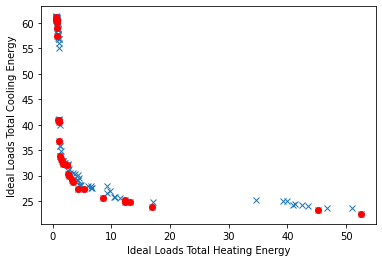

In [8]:
optres = results.loc[results['pareto-optimal']==True,:] # pareto-optimal
plt.plot(results['Heating demand (kWh/m²)'], results['Cooling demand (kWh/m²)'],'x') # Plot all results in 'x'
plt.plot(optres['Heating demand (kWh/m²)'], optres['Cooling demand (kWh/m²)'],'ro') # Plot of the best solutions in red
plt.xlabel('Ideal Loads Total Heating Energy')
plt.ylabel('Ideal Loads Total Cooling Energy')
plt.savefig("../results/h_envelope_wwr20_pareto.png")
#plt.axis([0.00,0.08,0.0,1.6]) #Set the dimension of the chart

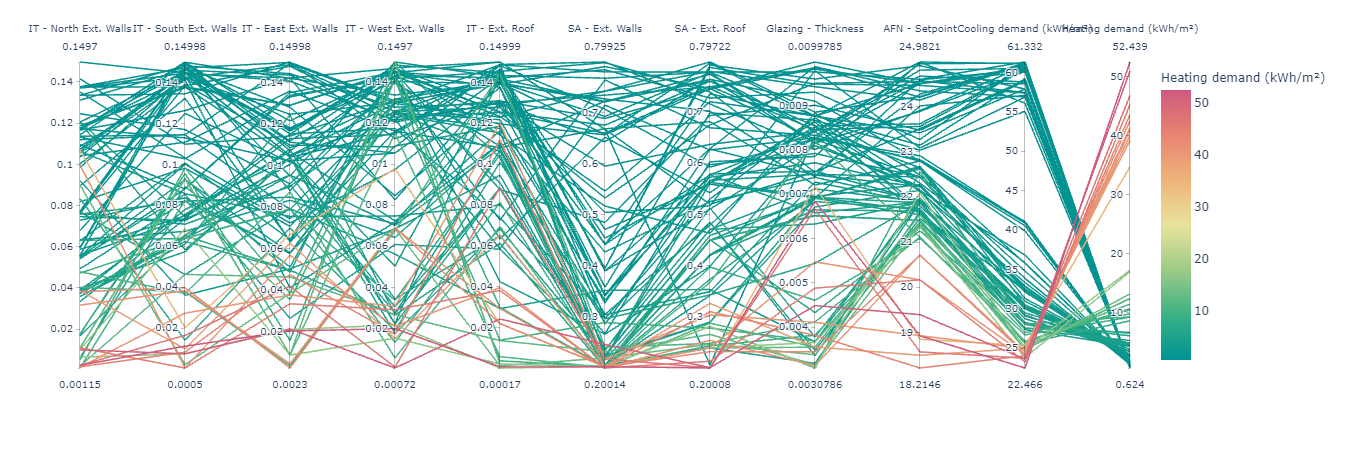

In [9]:
import plotly
plotly.offline.init_notebook_mode(connected=True)
import plotly.express as px
fig = px.parallel_coordinates(results,color="Heating demand (kWh/m²)", dimensions=["IT - North Ext. Walls","IT - South Ext. Walls","IT - East Ext. Walls","IT - West Ext. Walls","IT - Ext. Roof","SA - Ext. Walls","SA - Ext. Roof", "Glazing - Thickness", "AFN - Setpoint", "Cooling demand (kWh/m²)","Heating demand (kWh/m²)" ],
    color_continuous_scale=px.colors.diverging.Temps)
fig.show()

In [10]:
optres

,IT - North Ext. Walls,IT - South Ext. Walls,IT - East Ext. Walls,IT - West Ext. Walls,IT - Ext. Roof,SA - Ext. Walls,SA - Ext. Roof,Glazing - Thickness,AFN - Setpoint,Cooling demand (kWh/m²),Heating demand (kWh/m²),violation,pareto-optimal
0,0.002450,0.011173,0.020158,0.019923,0.000709,0.202639,0.200215,0.006837,18.926064,22.465728,52.438962,0,True
1,0.133527,0.148137,0.144333,0.127647,0.129824,0.734439,0.748411,0.009849,24.203285,61.108846,0.624405,0,True
2,0.010963,0.000499,0.033301,0.029075,0.038127,0.200167,0.213226,0.004880,20.164138,23.233098,45.231680,0,True
3,0.010095,0.068601,0.008520,0.015257,0.002117,0.202656,0.239228,0.003655,21.332851,23.779191,16.941592,0,True
4,0.117704,0.145120,0.116628,0.144465,0.149981,0.667641,0.206199,0.008314,24.569183,57.448371,0.793034,0,True
5,0.100277,0.139100,0.109850,0.108362,0.148192,0.706723,0.592193,0.008247,22.907831,40.934968,0.909299,0,True
6,0.017433,0.095514,0.015527,0.141741,0.029779,0.202802,0.243193,0.003819,21.367155,25.593693,8.613634,0,True
7,0.124588,0.116971,0.091254,0.139659,0.108774,0.722657,0.759674,0.008539,22.139012,36.805962,1.160273,0,True
8,0.016763,0.065413,0.095416,0.030561,0.087986,0.203882,0.373120,0.006830,21.743334,27.336166,5.278250,0,True
9,0.089997,0.002113,0.038387,0.068503,0.001204,0.219828,0.246427,0.003377,21.415113,24.776727,13.167757,0,True


In [11]:
results.to_csv('../results/h_envelope_wwr20_results.csv')

In [12]:
min_idealloads = results['Cooling demand (kWh/m²)']+results['Heating demand (kWh/m²)']
min_idealloads = min_idealloads[min_idealloads == min_idealloads.min()]
bestone = results[(results['Cooling demand (kWh/m²)']+results['Heating demand (kWh/m²)']) == min_idealloads.min()]
bestone

,IT - North Ext. Walls,IT - South Ext. Walls,IT - East Ext. Walls,IT - West Ext. Walls,IT - Ext. Roof,SA - Ext. Walls,SA - Ext. Roof,Glazing - Thickness,AFN - Setpoint,Cooling demand (kWh/m²),Heating demand (kWh/m²),violation,pareto-optimal
13,0.017704,0.092789,0.048447,0.149697,0.103138,0.205662,0.239228,0.003183,21.670088,27.356983,4.276447,0,True
